In [1]:
# %load_ext autoreload
# %autoreload 2

In [36]:
from src.data import pointcloud_processing, timeseries_processing
from src.data import config, pc_statistics
from src.data.config import TARGET_EXTENTS_VIF, TARGET_EXTENTS_VIF_SPLITS

import pandas as pd
from pointcloudset import PointCloud

import pickle

import matplotlib.pyplot as plt
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
import panel as pn

pn.extension("plotly")

#### Load Met Data from Bagfile

In [2]:
BAG_NAME_REFERENCE = "molisens_met_2023_08_07-15_36_45_converted"
DATA_DIR_REFERENCE = config.INTERIM_DATA_FOLDER / "ViF_Roof" / "data"
df_reference = timeseries_processing.load(
    DATA_DIR_REFERENCE / BAG_NAME_REFERENCE,
    "/sensing/aws/ws100_measurements",
    config.PATH_TO_LUFFT_MSGS,
    timestamp_source="header",
)

BAG_NAME_RAIN = "molisens_met_2023_08_29-06_04_46_converted"
DATA_DIR_RAIN = config.INTERIM_DATA_FOLDER / "ViF_Roof" / "data"
df_rain = timeseries_processing.load(
    DATA_DIR_RAIN / BAG_NAME_RAIN,
    "/sensing/aws/ws100_measurements",
    config.PATH_TO_LUFFT_MSGS,
    timestamp_source="header",
)

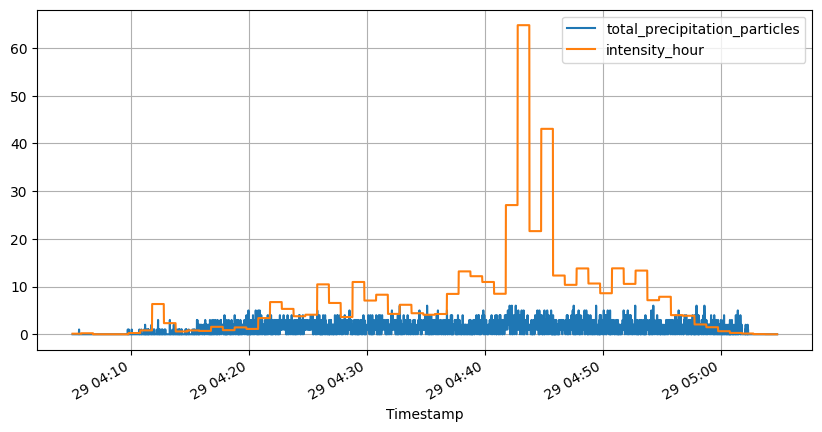

In [3]:
fig, ax = plt.subplots(figsize=(10, 5))
df_rain.precipitation.plot(y="total_precipitation_particles", use_index=True, ax=ax)
df_rain.precipitation.plot(y="intensity_hour", use_index=True, ax=ax)
plt.grid()

In [23]:
w_differ = df_rain.precipitation.differential.resample("10s").sum()
w_int_h = df_rain.precipitation.intensity_hour.resample("1S").mean()
# Shift to account for the AWS averaging duration
w_int_h = w_int_h.shift(periods=-60, freq="S")

### Load PC data

In [4]:
TOPICS = {
    "lid_pts": "/sensing/lidar/points",
    "lid_pts2": "/sensing/lidar/points2",
    "rad_pts": "/sensing/radar/points",
}

In [5]:
dataset_reference = pointcloud_processing.load_pointcloudset(
    DATA_DIR_REFERENCE, BAG_NAME_REFERENCE, topic=TOPICS["lid_pts"], verbose=True, invert_axes=["x", "y"]
)
dataset_rain = pointcloud_processing.load_pointcloudset(
    DATA_DIR_RAIN, BAG_NAME_RAIN, topic=TOPICS["lid_pts"], verbose=True, invert_axes=["x", "y"]
)

Searching for pointcloudset files in:
/workspaces/MOLISENSext_analysis/data/2interim/ViF_Roof/data/pointcloudset/sensing_lidar_points/molisens_met_2023_0
8_07-15_36_45_converted

Dataset loaded from:
/workspaces/MOLISENSext_analysis/data/2interim/ViF_Roof/data/pointcloudset/sensing_lidar_points/molisens_met_2023_08_07-15_36_45_converted
start =    2023-08-07 13:36:48.072408
end =      2023-08-07 13:39:47.651742
duration = 0:02:59.579334
length =   1795
avg frequency =  10.00 Hz
Inverting axes: ['x', 'y']


Searching for pointcloudset files in:
/workspaces/MOLISENSext_analysis/data/2interim/ViF_Roof/data/pointcloudset/sensing_lidar_points/molisens_met_2023_0
8_29-06_04_46_converted

Dataset loaded from:
/workspaces/MOLISENSext_analysis/data/2interim/ViF_Roof/data/pointcloudset/sensing_lidar_points/molisens_met_2023_08_29-06_04_46_converted
start =    2023-08-29 04:05:19.853657
end =      2023-08-29 05:04:46.069975
duration = 0:59:26.216318
length =   35659
avg frequency =  10.00 Hz
Inverting axes: ['x', 'y']


### Resample Dataset to 1min

In [8]:
# Remove the first 20 seconds of the dataset. This should be done when loading data !!!!
path = config.PROCESSED_DATA_FOLDER / "rain_minutes.pickle"
if not path.exists():
    rain_ds_minutes = pointcloud_processing.resample_dataset(dataset_rain[20 * 10 :], "1min", statistics=["std", "sum"])

    # Save the resampled datasets to pickle
    with open(path, "wb") as handle:
        pickle.dump(rain_ds_minutes, handle, protocol=pickle.HIGHEST_PROTOCOL)
else:
    # load from pickle
    path = config.PROCESSED_DATA_FOLDER / "rain_minutes.pickle"
    with open(path, "rb") as handle:
        rain_ds_minutes = pickle.load(handle)

## Target Statistics

In [27]:
rain_ds_minutes_mean = {}
for target_name, target_limits in TARGET_EXTENTS_VIF.items():
    rain_ds_minutes_mean[target_name] = (
        rain_ds_minutes["mean"].apply(target_limits.apply_limits).apply(pc_statistics.mean_intesity)
    )

### Result plots

In [29]:
colors = [
    "#1f77b4",  # muted blue
    "#ff7f0e",  # safety orange
    "#2ca02c",  # cooked asparagus green
    "#d62728",  # brick red
    "#9467bd",  # muted purple
    "#8c564b",  # chestnut brown
]

fig = make_subplots(specs=[[{"secondary_y": True}]])
# fig.add_trace(go.Scatter(x=w_differ.index, y=w_differ*200, mode='lines', name='differential precipitation', line=dict(color='red')))
fig.add_trace(
    go.Scattergl(x=w_int_h.index, y=w_int_h, mode="lines", name="Rainfall Rate", line=dict(color="#000080", width=3))
)

for col, (target_name, rain_ds_minutes_mean_ds) in zip(colors, rain_ds_minutes_mean.items()):
    fig.add_trace(
        go.Scatter(
            x=rain_ds_minutes_mean_ds.index,
            y=rain_ds_minutes_mean_ds,
            mode="lines",
            name=target_name,
            line=dict(color=col, width=2),
        ),
        secondary_y=True,
    )

fig.update_layout(
    template="ggplot2",
    autosize=False,
    width=1000,
    height=500,
    # title="Rainfall Rate vs. Noise in Pointclouds",
    legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=0.8),
    xaxis_title="",
    yaxis_title="Rainfall Rate [mm/h]",
    yaxis2_title="Mean Intensity",
    font=dict(size=16),
)
fig.update_yaxes(title_font_color="#000080")
fig.update_yaxes(title_font_color="#d5196e", secondary_y=True)

#### Plot only parts

In [30]:
colors = [
    "#1f77b4",  # muted blue
    "#ff7f0e",  # safety orange
    "#2ca02c",  # cooked asparagus green
    "#d62728",  # brick red
    "#9467bd",  # muted purple
    "#8c564b",  # chestnut brown
]

fig = make_subplots(specs=[[{"secondary_y": True}]])
# fig.add_trace(go.Scatter(x=w_differ.index, y=w_differ*200, mode='lines', name='differential precipitation', line=dict(color='red')))
fig.add_trace(
    go.Scattergl(x=w_int_h.index, y=w_int_h, mode="lines", name="Rainfall Rate", line=dict(color="#000080", width=3))
)

for col, (target_name, rain_ds_minutes_mean_ds) in zip(colors, rain_ds_minutes_mean.items()):
    if target_name in ["Target 2", "Ring Sensor"]:
        continue
    fig.add_trace(
        go.Scatter(
            x=rain_ds_minutes_mean_ds.index,
            y=rain_ds_minutes_mean_ds,
            mode="lines",
            name=target_name,
            line=dict(color=col, width=2),
        ),
        secondary_y=True,
    )

fig.update_layout(
    template="ggplot2",
    autosize=False,
    width=1000,
    height=500,
    # title="Rainfall Rate vs. Noise in Pointclouds",
    legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=0.8),
    xaxis_title="",
    yaxis_title="Rainfall Rate [mm/h]",
    yaxis2_title="Mean Intensity",
    font=dict(size=16),
)
fig.update_yaxes(title_font_color="#000080")
fig.update_yaxes(title_font_color="#d5196e", secondary_y=True)

### Spearate by intensity

In [35]:
rain_ds_minutes_targets

{'Target 1': Dataset([Delayed('pipeline_delayed-bdb53822-23d8-4609-b443-c0276c2c1726'), Delayed('pipeline_delayed-932f0998-abb0-495b-adbe-75ff770ce193'), Delayed('pipeline_delayed-27334ac7-2361-4933-bf0b-4beff70ba903'), Delayed('pipeline_delayed-2edc10c5-a9d5-4704-8fe7-16741e336e4b'), Delayed('pipeline_delayed-6d86104f-d603-418c-9a66-9e6b52e1d3ed'), Delayed('pipeline_delayed-89bb2ced-060f-417a-9130-3bf9275a08dc'), Delayed('pipeline_delayed-c045cab1-7ebb-47d4-aad9-9ac0f4611472'), Delayed('pipeline_delayed-71b988bc-dc82-410d-b156-64c70aff5542'), Delayed('pipeline_delayed-29d5e817-eecc-4c76-976e-a8fe0b5e90e6'), Delayed('pipeline_delayed-dd4e5561-d60d-4666-b81a-cb37b16f7200'), Delayed('pipeline_delayed-2d33d6d4-294c-4da5-96d2-b1b5fe534ca7'), Delayed('pipeline_delayed-329f195f-b04c-4682-a10d-19bd46d5a886'), Delayed('pipeline_delayed-5c57a1c9-4762-4b72-9cd0-faa07ef7a58d'), Delayed('pipeline_delayed-df630f03-e287-4ba1-95e4-1f683611adb2'), Delayed('pipeline_delayed-e60106e3-b0c9-48e2-89d4-dffd

In [ ]:
rain_ds_minutes_mean_intens = {}
for target_name, dic in TARGET_EXTENTS_VIF_SPLITS.items():
    for col, target_limits in dic:
        pass
    rain_ds_minutes_mean_intens[target_name] = (
        rain_ds_minutes["mean"].apply(target_limits.apply_limits).apply(pc_statistics.mean_intesity)
    )

<Axes: xlabel='Timestamp'>

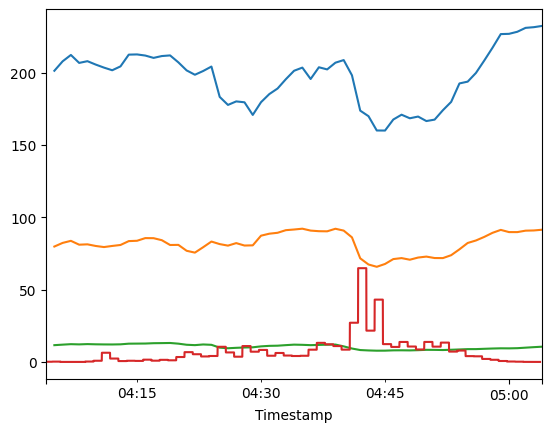

In [50]:
pd.concat(
    rain_ds_minutes["mean"]
    .apply(TARGET_EXTENTS_VIF_SPLITS["Target 1"]["white"].apply_limits)
    .apply(pc_statistics.mean_intesity)
).plot()
pd.concat(
    rain_ds_minutes["mean"]
    .apply(TARGET_EXTENTS_VIF_SPLITS["Target 1"]["grey"].apply_limits)
    .apply(pc_statistics.mean_intesity)
).plot()
pd.concat(
    rain_ds_minutes["mean"]
    .apply(TARGET_EXTENTS_VIF_SPLITS["Target 1"]["black"].apply_limits)
    .apply(pc_statistics.mean_intesity)
).plot()
w_int_h.plot()